# Final Model Comparison and Model Selection

This notebook provides a comprehensive comparison between all developed models
including Machine Learning, Deep Learning, and Transformer architectures.

The comparison considers predictive performance, computational efficiency,
generalization ability, and deployment suitability in order to identify the
best overall model.

In [1]:
# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
import joblib
from pathlib import Path

sns.set_theme(
    style="whitegrid",
    font_scale=1.1
)

plt.rcParams["figure.figsize"] = (10,6)



## Project Structure

In [2]:
# Mount Google Drive (Google Colab only)

try:
    from google.colab import drive

    drive.mount("/content/drive")
    BASE_DIR = Path("/content/drive/MyDrive/Mental_Health_Classification")

except:
    print("Running outside Google Colab...")
    BASE_DIR = Path.cwd()

PROJECT_DIR = BASE_DIR
DATA_DIR = PROJECT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
MODELS_DIR = PROJECT_DIR / "models"
TOKENIZERS_DIR = PROJECT_DIR / "tokenizers"
ENCODERS_DIR = PROJECT_DIR / "encoders"
RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = PROJECT_DIR / "figures"
NOTEBOOKS_DIR = PROJECT_DIR / "notebooks"
DEPLOYMENT_DIR = PROJECT_DIR / "deployment"

print("Project directories loaded successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directories loaded successfully.


## Load Results

In [3]:
# Machine Learning

ml_results = joblib.load(
    RESULTS_DIR / "baseline_models_summary.pkl"
)

optimized_lr = joblib.load(
    RESULTS_DIR / "optimized_logistic_regression_metrics.pkl"
)

optimized_lr = pd.DataFrame([optimized_lr])

ml_results = pd.concat(
    [ml_results, optimized_lr],
    ignore_index=True
)

if "Rank" in ml_results.columns:
    ml_results = ml_results.drop(columns="Rank")

ml_results = (
    ml_results
    .sort_values(
        "Weighted F1",
        ascending=False
    )
    .reset_index(drop=True)
)

ml_results.insert(
    0,
    "Rank",
    range(1, len(ml_results)+1)
)


# Deep Learning

dl_results = pd.read_csv(
    RESULTS_DIR / "dl_results.csv"
)


# Transformer

deberta_metrics = pd.read_csv(
    RESULTS_DIR / "deberta_metrics.csv"
)

deberta_history = pd.read_csv(
    RESULTS_DIR / "deberta_training_history.csv"
)

print("All experiment results loaded.")

All experiment results loaded.


In [4]:
deberta_train_time = deberta_history["train_time"].sum()

deberta_inference_time = deberta_history["validation_time"].mean()

deberta_train_time

np.float64(7068.23)

In [5]:
deberta_row = {

    "Model": "DeBERTa V3",

    "Accuracy":

        deberta_metrics.loc[
            deberta_metrics["Metric"]=="Accuracy",
            "Score"
        ].values[0],

    "Precision":

        deberta_metrics.loc[
            deberta_metrics["Metric"]=="Precision",
            "Score"
        ].values[0],

    "Recall":

        deberta_metrics.loc[
            deberta_metrics["Metric"]=="Recall",
            "Score"
        ].values[0],

    "Weighted F1":

        deberta_metrics.loc[
            deberta_metrics["Metric"]=="Weighted F1",
            "Score"
        ].values[0],

    "Macro F1":

        deberta_metrics.loc[
            deberta_metrics["Metric"]=="Macro F1",
            "Score"
        ].values[0],

    "Train Time (s)":

        deberta_train_time,

    "Inference Time (s)":

        deberta_inference_time
}

## Combine All Models

In [6]:
comparison = pd.concat(

    [
        ml_results.drop(columns="Rank"),
        dl_results,
        pd.DataFrame([deberta_row])
    ],

    ignore_index=True
)

In [7]:
comparison = (

    comparison
    .sort_values(

        "Weighted F1",
        ascending=False
    )

    .reset_index(drop=True)
)

In [9]:
comparison["Rank"] = range(1, len(comparison)+1)

In [10]:
comparison

,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1,Train Time (s),Inference Time (s),Rank
0,DeBERTa V3,0.840396,0.840812,0.840396,0.840141,0.830485,7068.230000,50.394000,1
1,Bidirectional LSTM,0.767639,0.780114,0.767639,0.771493,0.734425,19588.907847,130.513079,2
2,Optimized Logistic Regression,0.766340,0.776358,0.766340,0.766844,0.732854,21.851709,0.022702,3
3,Logistic Regression,0.769638,0.766709,0.769638,0.763319,0.712903,19.292922,0.010369,4
4,XGBoost,0.766240,0.763072,0.766240,0.762957,0.723617,818.105881,0.302258,5
5,Linear SVM,0.761643,0.756456,0.761643,0.756903,0.710252,15.593566,0.010578,6
6,Baseline LSTM,0.747651,0.774829,0.747651,0.754286,0.700064,6676.044541,82.083390,7
7,Multinomial Naive Bayes,0.702778,0.709696,0.702778,0.687245,0.583510,0.200633,0.011764,8
8,Random Forest,0.684789,0.716057,0.684789,0.656980,0.520841,456.704032,1.255690,9


## Overall Performance Comparison

In [13]:
comparison.style\
    .format({

        "Accuracy":"{:.4f}",
        "Precision":"{:.4f}",
        "Recall":"{:.4f}",
        "Weighted F1":"{:.4f}",
        "Macro F1":"{:.4f}",
        "Train Time (s)":"{:.2f}",
        "Inference Time (s)":"{:.4f}"

    })\
    .background_gradient(

        subset=[

            "Accuracy",
            "Weighted F1",
            "Macro F1"

        ],

        cmap="Greens"

    )

,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1,Train Time (s),Inference Time (s),Rank
0,DeBERTa V3,0.8404,0.8408,0.8404,0.8401,0.8305,7068.23,50.3940,1
1,Bidirectional LSTM,0.7676,0.7801,0.7676,0.7715,0.7344,19588.91,130.5131,2
2,Optimized Logistic Regression,0.7663,0.7764,0.7663,0.7668,0.7329,21.85,0.0227,3
3,Logistic Regression,0.7696,0.7667,0.7696,0.7633,0.7129,19.29,0.0104,4
4,XGBoost,0.7662,0.7631,0.7662,0.7630,0.7236,818.11,0.3023,5
5,Linear SVM,0.7616,0.7565,0.7616,0.7569,0.7103,15.59,0.0106,6
6,Baseline LSTM,0.7477,0.7748,0.7477,0.7543,0.7001,6676.04,82.0834,7
7,Multinomial Naive Bayes,0.7028,0.7097,0.7028,0.6872,0.5835,0.20,0.0118,8
8,Random Forest,0.6848,0.7161,0.6848,0.6570,0.5208,456.70,1.2557,9


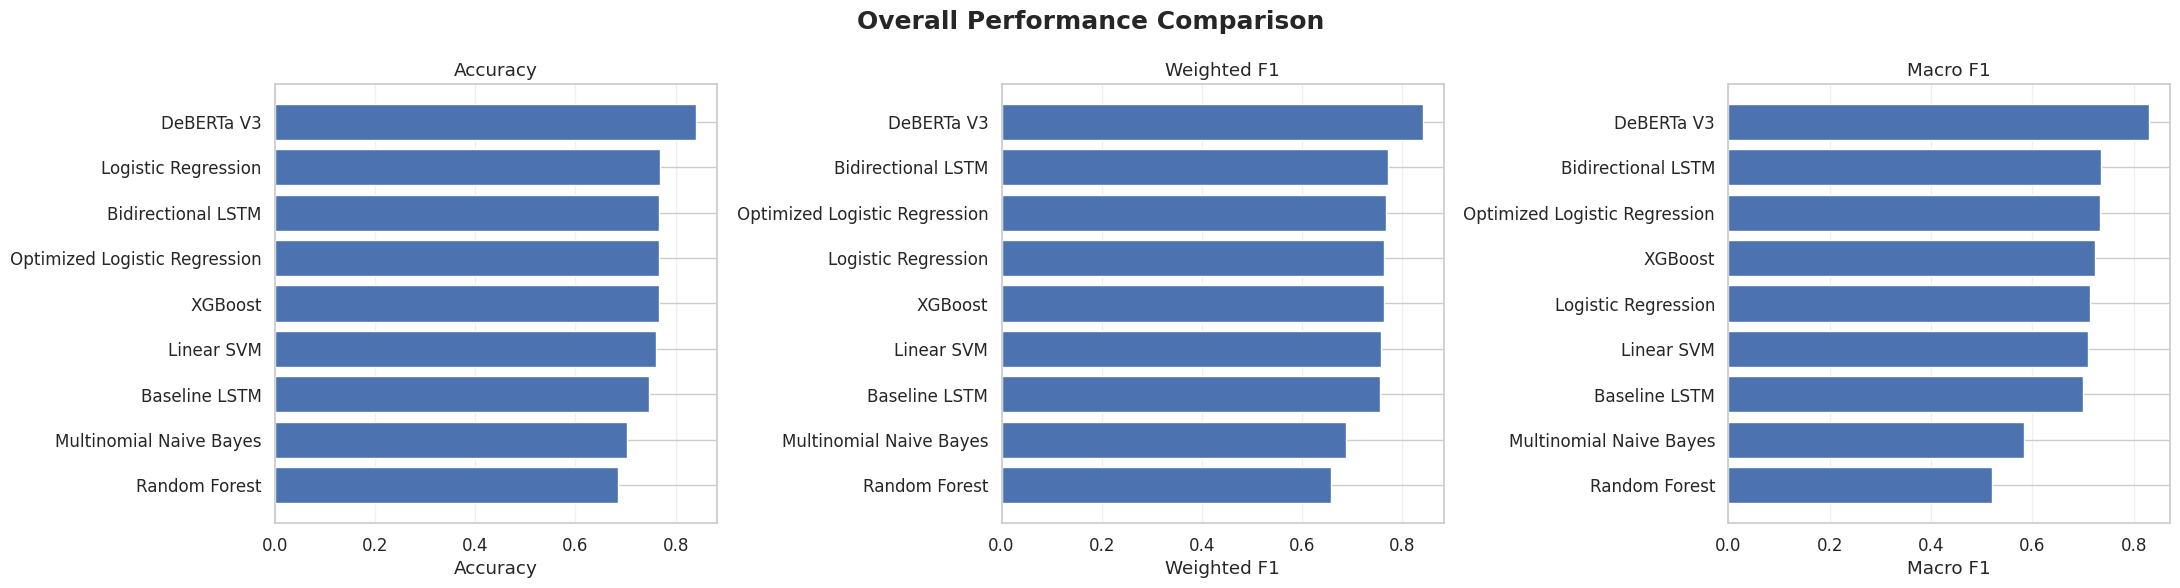

In [26]:
## Overall Performance Dashboard

fig, axes = plt.subplots(
    1,
    3,
    figsize=(22,6)
)

metrics = [
    ("Accuracy", axes[0]),
    ("Weighted F1", axes[1]),
    ("Macro F1", axes[2])
]

for metric, ax in metrics:

    plot_df = (
        comparison
        .sort_values(metric, ascending=True)
    )

    ax.barh(
        plot_df["Model"],
        plot_df[metric]
    )

    ax.set_title(metric)
    ax.set_xlabel(metric)
    ax.grid(axis="x", alpha=0.3)

plt.suptitle(
    "Overall Performance Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

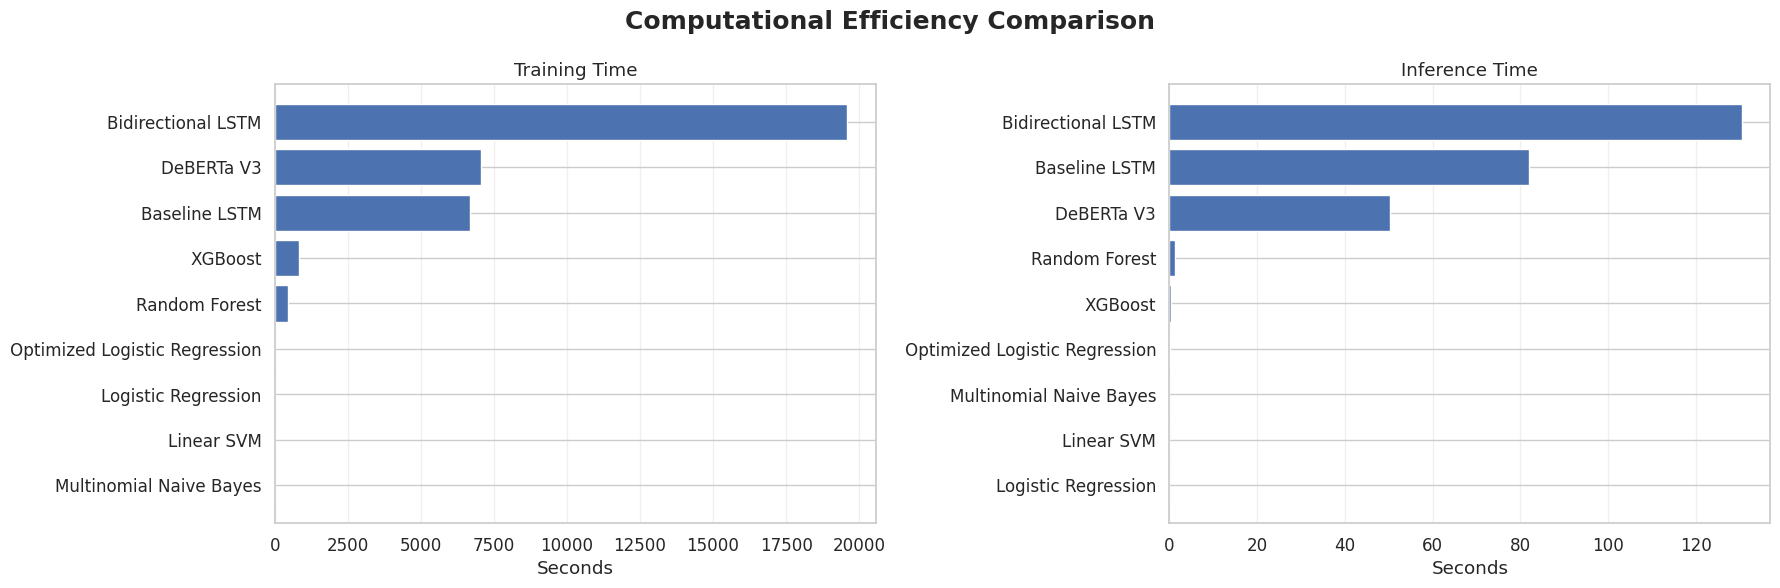

In [27]:
## Computational Efficiency Dashboard

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18,6)
)

# Training Time

train_df = comparison.sort_values(
    "Train Time (s)",
    ascending=True
)

axes[0].barh(
    train_df["Model"],
    train_df["Train Time (s)"]
)

axes[0].set_title("Training Time")
axes[0].set_xlabel("Seconds")
axes[0].grid(axis="x", alpha=0.3)

# Inference Time

infer_df = comparison.sort_values(
    "Inference Time (s)",
    ascending=True
)

axes[1].barh(
    infer_df["Model"],
    infer_df["Inference Time (s)"]
)

axes[1].set_title("Inference Time")
axes[1].set_xlabel("Seconds")
axes[1].grid(axis="x", alpha=0.3)

plt.suptitle(
    "Computational Efficiency Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## Performance vs Training Time

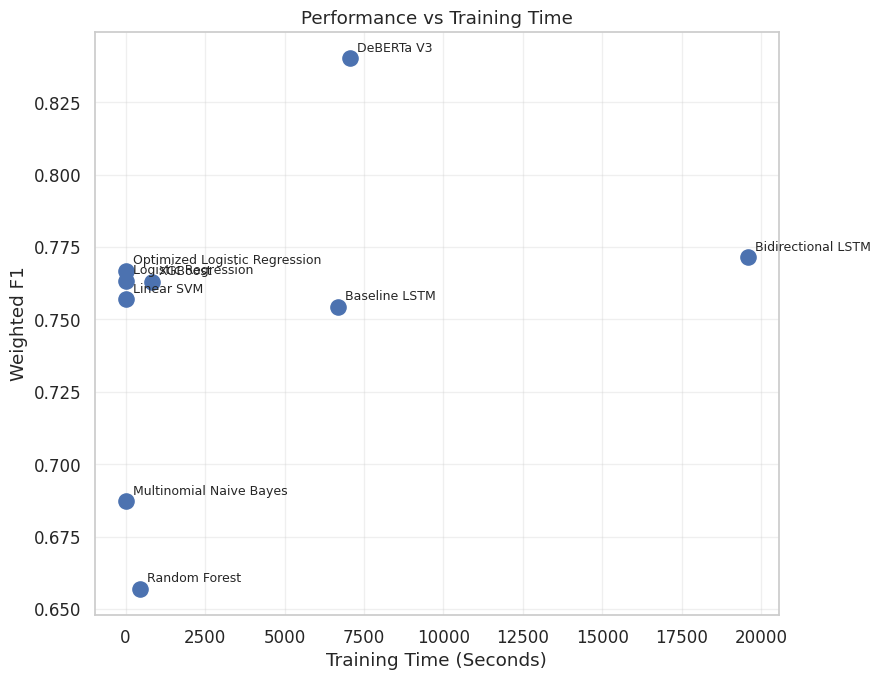

In [28]:
plt.figure(figsize=(9,7))

plt.scatter(
    comparison["Train Time (s)"],
    comparison["Weighted F1"],
    s=120
)

for _, row in comparison.iterrows():

    plt.annotate(

        row["Model"],

        (
            row["Train Time (s)"],
            row["Weighted F1"]
        ),

        xytext=(5,5),
        textcoords="offset points",
        fontsize=9
    )

plt.xlabel("Training Time (Seconds)")
plt.ylabel("Weighted F1")
plt.title("Performance vs Training Time")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Performance vs Inference Time

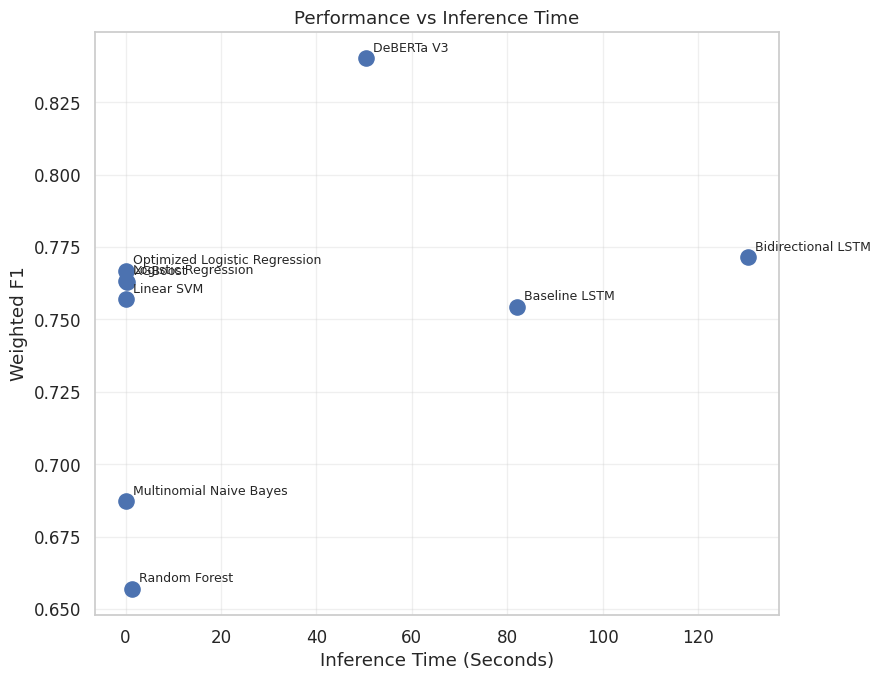

In [29]:
plt.figure(figsize=(9,7))

plt.scatter(

    comparison["Inference Time (s)"],
    comparison["Weighted F1"],
    s=120
)

for _, row in comparison.iterrows():

    plt.annotate(

        row["Model"],

        (
            row["Inference Time (s)"],
            row["Weighted F1"]
        ),

        xytext=(5,5),
        textcoords="offset points",
        fontsize=9
    )

plt.xlabel("Inference Time (Seconds)")
plt.ylabel("Weighted F1")
plt.title("Performance vs Inference Time")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

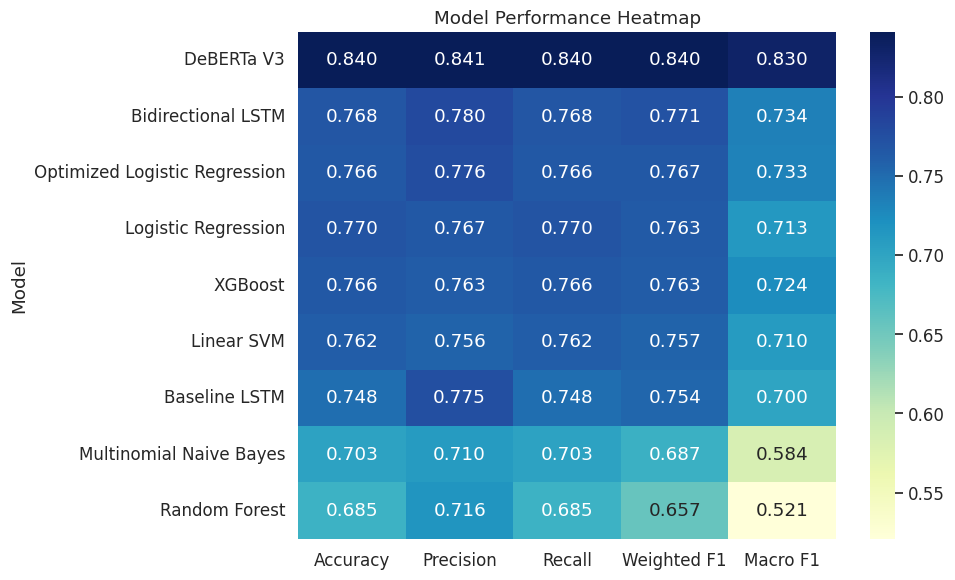

In [30]:
## Metrics Heatmap

heatmap_df = (

    comparison
    .set_index("Model")

    [[
        "Accuracy",
        "Precision",
        "Recall",
        "Weighted F1",
        "Macro F1"
    ]]
)

plt.figure(figsize=(10,6))

sns.heatmap(

    heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu"
)

plt.title("Model Performance Heatmap")
plt.tight_layout()
plt.show()

# Model Selection Criteria

Selecting the best model requires more than comparing accuracy alone.

A practical machine learning system should achieve strong predictive
performance while maintaining reasonable computational efficiency and good
generalization capability.

The following criteria are considered during model selection:

- Classification Accuracy
- Weighted F1-score
- Macro F1-score
- Training Time
- Inference Time
- Generalization Performance
- Deployment Suitability

Although accuracy is widely reported, the Weighted F1-score is considered the
primary evaluation metric because it provides a more balanced assessment for
the imbalanced multi-class mental health dataset used in this project.

In [33]:
strengths = pd.DataFrame({

    "Model":[

        "Logistic Regression",
        "Optimized Logistic Regression",
        "Linear SVM",
        "XGBoost",
        "Random Forest",
        "Multinomial Naive Bayes",
        "Baseline LSTM",
        "Bidirectional LSTM",
        "DeBERTa V3"

    ],

    "Strengths":[

        "Fast training and inference, simple deployment",
        "Improved F1-score while maintaining efficiency",
        "Good linear classifier with low inference time",
        "Strong ensemble performance",
        "Robust tree-based learning",
        "Extremely fast training",
        "Captures sequential information",
        "Captures bidirectional context",
        "Highest contextual understanding and best overall performance"

    ],

    "Weaknesses":[

        "Limited contextual understanding",
        "Slightly slower than baseline LR",
        "Limited to linear decision boundaries",
        "Long training time",
        "Lowest performance",
        "Lowest predictive performance",
        "Moderate computational cost",
        "Very expensive training",
        "Requires GPU and transformer infrastructure"
    ]

})

strengths

,Model,Strengths,Weaknesses
0,Logistic Regression,"Fast training and inference, simple deployment",Limited contextual understanding
1,Optimized Logistic Regression,Improved F1-score while maintaining efficiency,Slightly slower than baseline LR
2,Linear SVM,Good linear classifier with low inference time,Limited to linear decision boundaries
3,XGBoost,Strong ensemble performance,Long training time
4,Random Forest,Robust tree-based learning,Lowest performance
5,Multinomial Naive Bayes,Extremely fast training,Lowest predictive performance
6,Baseline LSTM,Captures sequential information,Moderate computational cost
7,Bidirectional LSTM,Captures bidirectional context,Very expensive training
8,DeBERTa V3,Highest contextual understanding and best over...,Requires GPU and transformer infrastructure


## Best Model Analysis

Among all evaluated models, **DeBERTa V3** achieved the highest overall
performance.

It obtained:

- Highest Accuracy
- Highest Weighted F1-score
- Highest Macro F1-score

Compared with the classical machine learning algorithms, the transformer
architecture demonstrated a significantly stronger ability to capture complex
semantic relationships and contextual information within mental health
statements.

Although DeBERTa required substantially more computational resources than
traditional machine learning models, its predictive performance justified this
additional cost.

The Bidirectional LSTM achieved competitive results but required considerably
longer training time while still underperforming the transformer model.

Classical machine learning models, particularly Logistic Regression and
Linear SVM, remained attractive alternatives for lightweight deployment due
to their extremely fast inference speed and relatively strong performance.

## Final Recommendation

Based on the comprehensive evaluation, **DeBERTa V3** is selected as the
final model for deployment.

The selection is supported by the following observations:

- It achieved the highest predictive performance across all evaluation
  metrics.

- It demonstrated superior contextual understanding compared with recurrent
  neural networks.

- It generalized well on unseen test data.

- It produced the best balance between precision and recall for all mental
  health classes.

For environments with limited computational resources, Optimized Logistic
Regression provides an excellent lightweight alternative due to its fast
training, extremely low inference time, and competitive classification
performance.

# Executive Summary

Nine different machine learning, deep learning, and transformer-based models
were evaluated for multi-class mental health text classification.

The comparison demonstrated that transformer architectures consistently
outperformed both classical machine learning and recurrent neural network
models.

Among all evaluated models, DeBERTa V3 achieved the best overall performance,
obtaining the highest Accuracy, Weighted F1-score, and Macro F1-score.

For resource-constrained environments, Optimized Logistic Regression remains
a strong alternative due to its excellent trade-off between predictive
performance and computational efficiency.

Overall, DeBERTa V3 is selected as the final deployment model for this
project.